# Lab 3: Neural Networks: Feedforward Networks and the Training Process

**Duration:** 1 week [21 Jul - 28 Jul, 2026]
**Due Date:** 28th July, 2026
**Format:** Jupyter Notebook / Google Colab
**Grading:** This is a graded lab.

**Student Name:** Kekeli Yao Agblobi
**Student ID:** 45862028

---

### Objective

This lab bridges the gap between classical ML and deep learning. Instead of calling
`.fit()` and trusting scikit-learn, you will **open the black box**: build a neural network
from a single neuron upward, watch gradient descent learn, and then train a full
**feedforward network (MLP) in PyTorch** on a dataset you already know from Lab 2.

By the end you should be able to explain, and demonstrate with your own plots, what each
of these really does: **weights, activation functions, loss, gradients, learning rate,
epochs, batches, and overfitting**.

We deliberately stay on **tabular data** this week. Images and CNNs come in the next lab.

---
### Part 0: Repository Setup *(done outside this notebook)*

1. Create a **public** repository named `lab-3` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_3.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas matplotlib scikit-learn torch`.
5. Commit and push after completing **each Part** below — we will check your commit history.
   A single "final commit" with everything at once loses marks.

In [ ]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


---
# Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent

Before touching PyTorch's automation, you will build the moving parts **yourself with NumPy**
on a toy problem, so that nothing later in the lab is magic.

The toy problem: learn the function `y = sin(x)` on the interval `[-3, 3]` from 100 noisy
samples. It is 1-dimensional, so we can *plot everything* — the data, the model's prediction,
and the loss going down.

### Part 1.1 — A single neuron is just a line
A neuron computes `y_hat = w * x + b`. Fit it to the sine data with **manual gradient descent**.

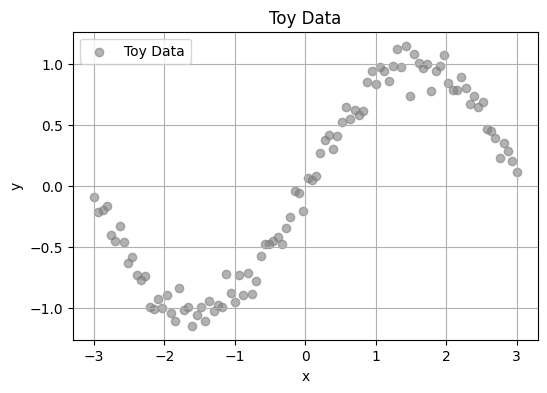

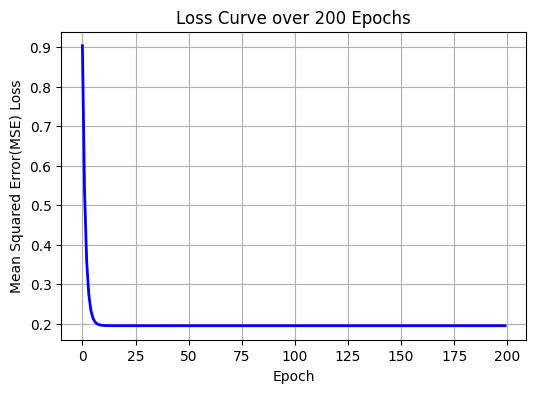

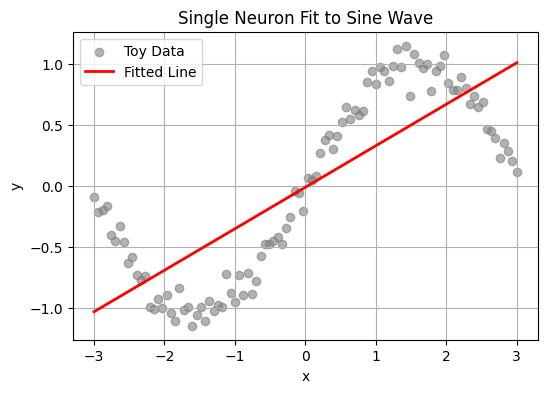

In [ ]:
# TODO: Generate the toy data
#   x = np.linspace(-3, 3, 100); y = np.sin(x) + small Gaussian noise (std=0.1)
#   Plot it.
std=0.1
x = np.linspace(-3, 3, 100)
y = np.sin(x)+np.random.normal(0, std, size=x.shape)


plt.figure(figsize=(6, 4))
plt.scatter(x, y, color='gray', alpha=0.6, label='Toy Data')
plt.title('Toy Data')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()


# TODO: Initialise w and b to small random values.
w = np.random.randn() * 0.1
b = np.random.randn() * 0.1

#Learing rate
lr=0.05
losses=[]

# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:


#   y_hat = w * x + b
#   loss  = np.mean((y_hat - y) ** 2)               # MSE
#   dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw  (derive this on paper!)
#   db    = np.mean(2 * (y_hat - y))                # dLoss/db
#   w    -= lr * dw
#   b    -= lr * db
#   Record the loss at every step.

for epoch in range(200):
  y_hat = w * x + b

  #Mean Squared Error loss
  loss = np.mean((y_hat - y) ** 2)
  losses.append(loss)

  dw = np.mean(2 * (y_hat - y) * x)
  db = np.mean(2 * (y_hat - y))
  w -= lr * dw
  b -= lr * db

# TODO: Plot (a) the loss curve over the 200 steps, and
#             (b) the data with the fitted line on top.

#(a)
plt.figure(figsize=(6, 4))
plt.plot(losses, color='blue', linewidth=2)
plt.title('Loss Curve over 200 Epochs')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error(MSE) Loss')
plt.grid(True)
plt.show()

#(b)
plt.figure(figsize=(6, 4))
plt.scatter(x, y, color='gray', alpha=0.6, label='Toy Data')
plt.plot(x, y_hat, color='red', linewidth=2, label='Fitted Line')
plt.title('Single Neuron Fit to Sine Wave')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()




**Student Reasoning — The single neuron**
*1. Derive `dLoss/dw` on paper and include a photo or the LaTeX in this cell — does it match
the code?*
*2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting,
and WHY can a single neuron never fit a sine wave, no matter how long you train?*

> **Answer:**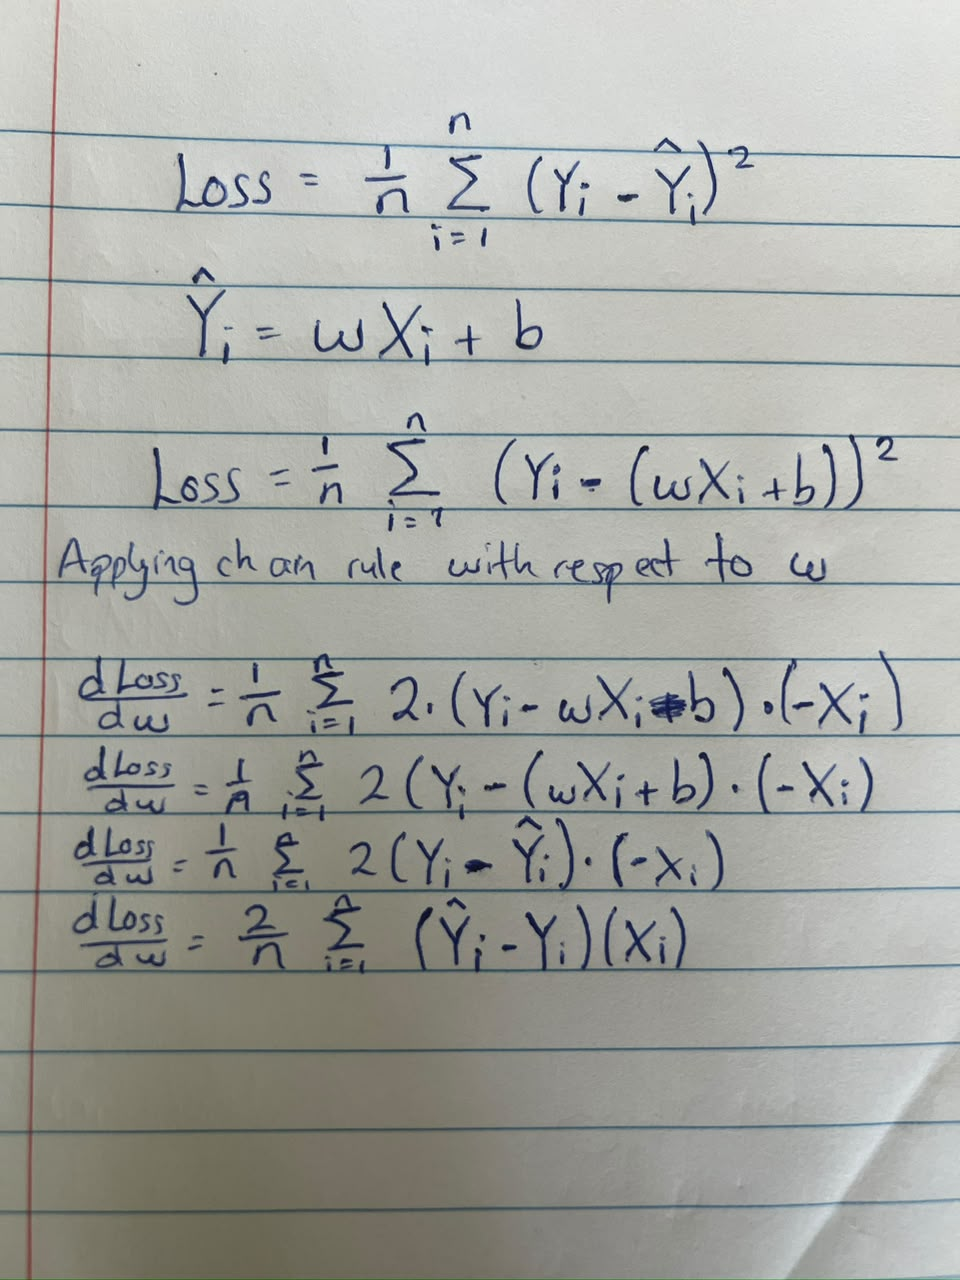

Yes. In Python dw = np.mean(2 * (y_hat - y) * x) calculates  the dLoss/dw across all 100 samples simultaneously, which is the exact vectorized form of the derivative.

The model is clearly underfitting since its shown as a straight line trying to follow the curved line. A single neuron with no activation function computes a simple linear equation (y_hat = w * x + b) which renders it as a straight line. Because y = np.sin(x)+np.random.normal(0, std, size=x.shape) which is curved, there is no way to combine w and b to bend the line no matter the number of epochs


### Part 1.2 — Hidden layers and activations: why depth helps
Now build a tiny network **by hand**: 1 input -> a hidden layer of 8 neurons with `tanh` ->
1 output. Still NumPy, still manual gradients.

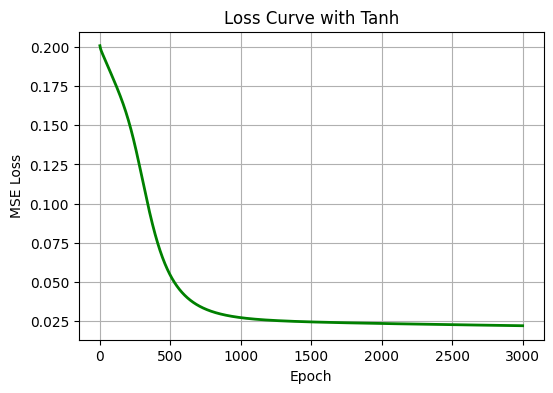

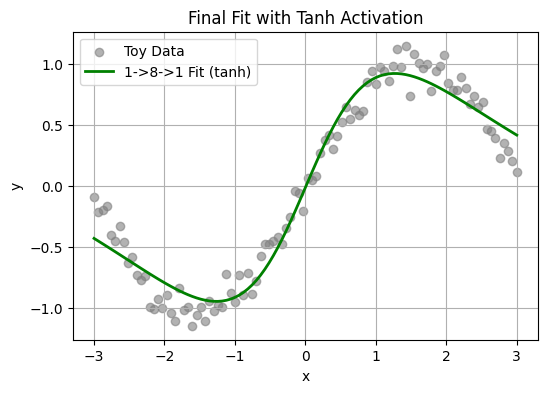

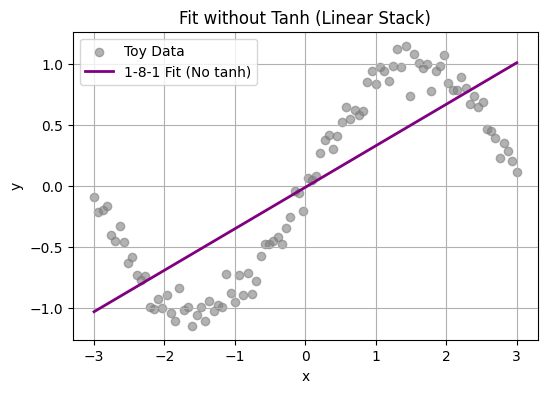

In [ ]:
#Without reshaping, it kept throwing a ValueError.
x = x.reshape(-1, 1)  # Shape becomes (100, 1)
y = y.reshape(-1, 1)


# TODO: Initialise parameters
#   W1: shape (1, 8),  b1: shape (8,)
#   W2: shape (8, 1),  b2: shape (1,)
#   Small random values (e.g. np.random.randn(...) * 0.5)
W1 = np.random.randn(1, 8) * 0.5
b1 = np.zeros((1, 8))
W2 = np.random.randn(8, 1) * 0.5
b2 = np.zeros((1, 1))

lr=0.01
loss_with_tanh=[]


for epoch in range(3000):
  # TODO: Forward pass (keep the intermediate values — you need them for backprop):
  z1 = x @ W1 + b1  # pre-activation, shape (100, 8)
  h = np.tanh(z1)   # activation
  y_hat = h @ W2 + b2   # output, shape (100, 1)
  loss  = np.mean((y_hat - y) ** 2)
  loss_with_tanh.append(loss)

  # TODO: Backward pass (the chain rule, layer by layer):
  d_yhat = 2 * (y_hat - y) / len(y)
  dW2 = h.T @ d_yhat
  db2 = d_yhat.sum(axis=0)

  dh  = d_yhat @ W2.T
  dz1 = dh * (1 - np.tanh(z1) ** 2)
  dW1 = x.T @ dz1
  db1 = dz1.sum(axis=0)

  # TODO: Update all parameters with learning rate lr, loop for ~3000 steps,
  #   record the loss.
  W2 -= lr * dW2
  b2 -= lr * db2
  W1 -= lr * dW1
  b1 -= lr * db1


# TODO: Plot the loss curve AND the final fit over the data.
#   Then re-run with the tanh REMOVED (h = z1). What happens to the fit?

plt.figure(figsize=(6, 4))
plt.plot(loss_with_tanh, color='green', linewidth=2)
plt.title('Loss Curve with Tanh')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.scatter(x, y, color='gray', alpha=0.6, label='Toy Data')
plt.plot(x, y_hat.flatten(), color='green', linewidth=2, label='1->8->1 Fit (tanh)')
plt.title('Final Fit with Tanh Activation')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

#Without tanh activation function
loss_without_tanh=[]

W1_lin = np.random.randn(1, 8) * 0.5
b1_lin = np.zeros((1, 8))
W2_lin = np.random.randn(8, 1) * 0.5
b2_lin = np.zeros((1, 1))

for epoch in range(3000):
  z1 = x @ W1_lin + b1_lin
  h = z1                      # Linear activation!
  y_hat_lin = h @ W2_lin + b2_lin
  loss = np.mean((y_hat_lin - y) ** 2)

  loss_without_tanh.append(loss)
  d_yhat = 2 * (y_hat_lin - y) / len(y)
  dW2_lin = h.T @ d_yhat
  db2_lin = d_yhat.sum(axis=0, keepdims=True)
  dh = d_yhat @ W2_lin.T
  dz1 = dh * 1.0              # Derivative of identity is 1
  dW1_lin = x.T @ dz1
  db1_lin = dz1.sum(axis=0, keepdims=True)

  W2_lin -= lr * dW2_lin
  b2_lin -= lr * db2_lin
  W1_lin -= lr * dW1_lin
  b1_lin -= lr * db1_lin

plt.figure(figsize=(6, 4))
plt.scatter(x, y, color='gray', alpha=0.6, label='Toy Data')
plt.plot(x, y_hat_lin.flatten(), color='purple', linewidth=2, label='1-8-1 Fit (No tanh)')
plt.title('Fit without Tanh (Linear Stack)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()



**Student Reasoning — Depth and activations**
*1. With tanh removed, the deep network fits no better than the single neuron of Part 1.1.
Explain mathematically why a stack of linear layers collapses into one linear layer.*
*2. What role did the hidden layer's 8 neurons play in fitting the curve? (Hint: plot a few
columns of `h` against `x`.)*
*3. This is exactly what `loss.backward()` will automate in Section 2. In one sentence, what
is backpropagation?*

> **Answer:**
1. Without the tanh, the hidden layer becomes z1 = x @ W1_lin + b1_lin. Substituting this in the y_hat_lin = (x @ W1_lin + b1_lin) @ W2_lin + b2_lin. Because multiplying two weight matrices (W1_lin, W2_lin) just gives you another single matrix, and (b1_lin*W2_lin + b2_lin) just gives a single bias vector, the whole network shrinks back down to y_hat=X*W_new + b_new. It's basically sends it back to being a single straight line similar to part 1.1

2. The 8 hidden neurons extract the features. Each neuron applies the non-linear tanh function to transform the input x into different curved functions. The output layer then takes a weighted combination of these 8 distinct curves to reconstruct the overall sine wave pattern.

3. Backpropagation is an algorithm that uses the mathematical chain rule to calculate the partial gradient of the loss function with respect to every weight and bias in the network by moving backward from output to input.

### Part 1.3 — The learning rate: too cold, too hot, just right
The single most important hyperparameter. See its three regimes with your own eyes.

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_3131/1465554722.py:19: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - Y) ** 2)
/tmp/ipykernel_3131/1465554722.py:26: RuntimeWarning: overflow encountered in matmul
  dh = d_yhat @ W2.T
/tmp/ipykernel_3131/1465554722.py:27: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)


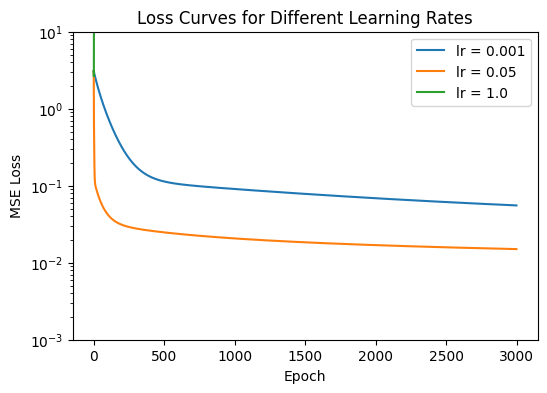

In [ ]:
# TODO: Wrap your Part 1.2 training loop in a function train_toy(lr, steps=3000)
#   that returns the list of losses.

def train_toy(lr,steps=3000):
  np.random.seed(RANDOM_STATE)
  X = x.reshape(-1, 1)
  Y = y.reshape(-1, 1)

  W1 = np.random.randn(1, 8) * 0.5
  b1 = np.zeros((1, 8))
  W2 = np.random.randn(8, 1) * 0.5
  b2 = np.zeros((1, 1))
  losses = []
  for epoch in range(steps):
    z1 = X @ W1 + b1
    h = np.tanh(z1)
    y_hat = h @ W2 + b2

    loss = np.mean((y_hat - Y) ** 2)
    losses.append(loss)

    d_yhat = 2 * (y_hat - Y) / len(Y)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0, keepdims=True)

    dh = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)
    dW1 = X.T @ dz1
    db1 = dz1.sum(axis=0, keepdims=True)

    W2 -= lr * dW2
    b2 -= lr * db2
    W1 -= lr * dW1
    b1 -= lr * db1
  return losses
# TODO: Run it with THREE learning rates, e.g. lr = 0.001, 0.05, 1.0
#   (keep the same initial weights for a fair comparison — reset the seed).
learning_rates = [0.001, 0.05, 1.0]
results = {}
for lr in learning_rates:
  results[lr] = train_toy(lr)

# TODO: Plot the three loss curves on the same axes (log scale on y helps), with a legend.
plt.figure(figsize=(6, 4))
for lr, loss in results.items():
    plt.plot(loss, label=f'lr = {lr}')
plt.ylim(1e-3, 10)
plt.title('Loss Curves for Different Learning Rates')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.yscale('log')
plt.legend()
plt.show()

**Student Reasoning — Learning rate**
*Describe what each of the three curves shows. Why does a too-large learning rate make the
loss explode or oscillate instead of just "learning faster"?*

> **Answer:**
 1. lr=0.001 : The loss decreases the slowest here, but takes steps that are too tiny to reach the optimal minimum within 3,000 steps.
2. lr=0.05 : The loss drops steadily and converges to a low minimum early in training.
3. lr=1.0 : The loss explodes early since the step size is  massive. This causes gradient descent to overshoot and move back and forth instead of converging. The learning rate caused
resulting tge runtime error warnings even.

 Gradient descent uses the local slope to estimate which way is downhill. When the learning rate is too big, the update step takes a giant leap past the minimum and lands much higher up on the opposite wall of the loss curve. Further steps keep overshooting further and further out, causing the loss to explode exponentially rather than converge.

---
# Section 2 — A Real Feedforward Network in PyTorch

Now we let PyTorch do the bookkeeping (`autograd`, optimizers, batching) and apply the ideas
from Section 1 to a real problem — one you already know:

## Predicting obesity level (`NObeyesdad`) — the Lab 2 dataset

Same data, same 7 classes, same preprocessing ideas — but this time the model is a neural
network you design and train yourself. At the end you will compare it head-to-head with your
Lab 2 classical models.

### Part 2.1 — Preprocess and split (recycled from Lab 2)
Reuse your Lab 2 pipeline: encode categoricals, scale numerics, stratified three-way split.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# TODO: Load the obesity dataset (same OBESITY_URL as Lab 2).
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
obesity = pd.read_csv(OBESITY_URL)

# TODO: Encode categoricals exactly as you did in Lab 2
binary_cols = ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']
for col in binary_cols:
    obesity[col] = obesity[col].map({'yes': 1, 'no': 0})

obesity = pd.get_dummies(obesity, columns=['Gender', 'CAEC', 'CALC', 'MTRANS'], drop_first=True)

le = LabelEncoder()
obesity['NObeyesdad'] = le.fit_transform(obesity['NObeyesdad'])

# TODO: Stratified train / validation / test split (60/20/20, stratify=y, random_state=RANDOM_STATE).
X = obesity.drop(columns=['NObeyesdad'])
y = obesity['NObeyesdad']

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=RANDOM_STATE
)

# TODO: Fit a StandardScaler on the TRAINING set only; transform all three splits.
#   (Neural networks are far more sensitive to feature scale than random forests —
#    remember Section 1, where all gradients depended on x!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# TODO: Convert to tensors and wrap in DataLoaders:
#   X -> torch.float32, y -> torch.long
#   train_loader (batch_size=32, shuffle=True), val_loader, test_loader
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)

X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Data successfully split & prepared:")
print(f"Train shape: {X_train_scaled.shape}, Val shape: {X_val_scaled.shape}, Test shape: {X_test_scaled.shape}")


Data successfully split & prepared:
Train shape: (1266, 23), Val shape: (422, 23), Test shape: (423, 23)


**Student Reasoning — Preprocessing for neural networks**
*1. Why does CrossEntropyLoss need integer class labels rather than one-hot vectors in
PyTorch?*
*2. A random forest in Lab 2 did not care about feature scaling. Why do neural networks care
so much? Connect your answer to the gradient formulas you wrote in Section 1.*
*3. What does `shuffle=True` on the training DataLoader do, and why does it help?*

> **Answer:**
1. In PyTorch, nn.CrossEntropyLoss needs target labels to be integer class indices rather than one-hot vectors since internally, it combines nn.LogSoftmax and nn.NLLLoss using the integer index directly to pick the correct logit for loss calculation efficiently.

2. Neural network weights and gradients are directly scaled by input magnitude as seen in the chain rule. Unscaled features with large ranges such as Weight, create severe gradient imbalances and distorted loss landscapes, causing optimization to destabilize. Random forests split along individual feature thresholds independently, making them invariant to monotonic feature scaling.

3. shuffle=True in a PyTorch training DataLoader mixes up the order of the dataset randomly at the start of every epoch, which stops the model from learning the order of the data and helps it learn better.

### Part 2.2 — Design the network
An MLP: input -> hidden layers with ReLU -> 7 output logits.

In [ ]:
# TODO: Define a FeedForwardNet class (subclass nn.Module) with:
#   - constructor args: input_dim, hidden_sizes=(64, 32), n_classes=7
#   - at least TWO hidden layers with ReLU activations
#     (NO softmax — nn.CrossEntropyLoss applies log-softmax internally)

# class FeedForwardNet(nn.Module):
#     def __init__(self, ...):
#         ...
#     def forward(self, x):
#         ...
class FeedForwardNet(nn.Module):
  def __init__(self,input_dim,hidden_sizes=(64,32),n_classes=7):
    super(FeedForwardNet,self).__init__()

    layers = []
    in_dim = input_dim

    for h_size in hidden_sizes:
        layers.append(nn.Linear(in_dim, h_size))
        layers.append(nn.ReLU())
        in_dim = h_size

    #   - output layer producing 7 raw logits
    layers.append(nn.Linear(in_dim, n_classes))
    self.network = nn.Sequential(*layers)

  def forward(self, x):
        return self.network(x)


# TODO: Instantiate, move to DEVICE, print the model.
input_dim = X_train_scaled.shape[1]
model=FeedForwardNet(input_dim=input_dim, hidden_sizes=(64, 32), n_classes=7).to(DEVICE)

print("Model Architecture")
print(model)

# TODO: Count trainable parameters:
#   sum(p.numel() for p in model.parameters() if p.requires_grad)
#   Verify the count for the FIRST layer by hand: input_dim * 64 + 64.
total_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_parameters}")
first_layer_parameters=input_dim * 64 + 64
print(f"First Layer count by hand: {input_dim} * 64 + 64 = {first_layer_parameters}")


Model Architecture
FeedForwardNet(
  (network): Sequential(
    (0): Linear(in_features=23, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=7, bias=True)
  )
)
Total trainable parameters: 3847
First Layer count by hand: 23 * 64 + 64 = 1536


**Student Reasoning — Architecture**
*1. Show the by-hand parameter count for every layer and confirm it matches PyTorch.*
*2. Why ReLU here instead of the tanh you used in Section 1? Name one advantage.*
*3. What would the network compute if you removed the ReLUs? (You proved this in Part 1.2.)*

> **Answer:**
1. Calculations

    Hidden Layer 1: (23x 64)+64=1536

    Hidden Layer 2: (64 x 32)+32=2080

    Output Layer: (32 x 7)+7=231

    Total Parameter = 1536 + 2080 + 231 = 3847

    It matches the PyTorch total

2. ReLU solves the vanishing gradient problem since its derivative is 1 for every x>0. Unlike tanh, whose gradients shrink towards 0 for large inputs, ReLU keeps gradients strong during backpropagation and is  faster to compute.

3.   Without ReLUs, the network collapses into a single linear transformation , as proven in Part 1.2.

### Part 2.3 — The training loop
The same loop you built by hand in Section 1 — now with autograd, an optimizer, and batches.

Epoch 01/50 | Train Loss: 1.8897 | Train Acc: 0.3207 | Val Loss: 1.7961 | Val Acc: 0.5640
Epoch 10/50 | Train Loss: 0.4284 | Train Acc: 0.8705 | Val Loss: 0.5102 | Val Acc: 0.8318
Epoch 20/50 | Train Loss: 0.1490 | Train Acc: 0.9700 | Val Loss: 0.3005 | Val Acc: 0.9005
Epoch 30/50 | Train Loss: 0.0643 | Train Acc: 0.9889 | Val Loss: 0.2522 | Val Acc: 0.9194
Epoch 40/50 | Train Loss: 0.0322 | Train Acc: 0.9984 | Val Loss: 0.2416 | Val Acc: 0.9265
Epoch 50/50 | Train Loss: 0.0182 | Train Acc: 1.0000 | Val Loss: 0.2502 | Val Acc: 0.9289


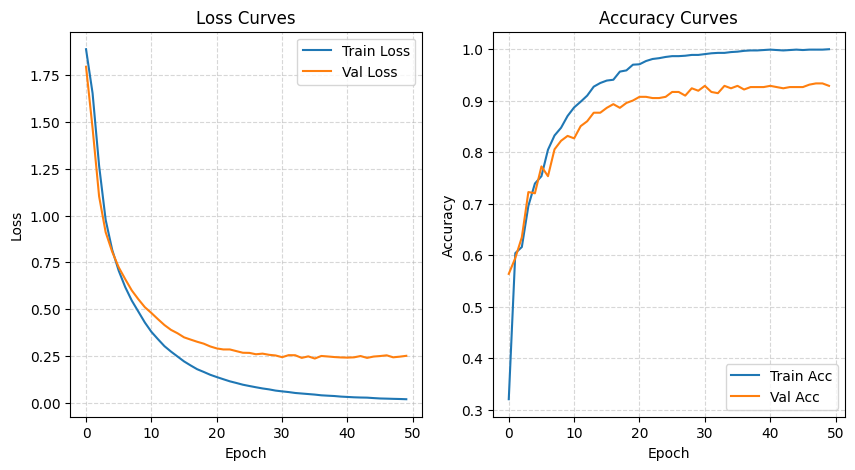

In [ ]:
import torch.optim as optim
# TODO:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs=50
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0.0

# TODO: Train for at least 50 epochs. Each epoch:
#   1. model.train(); for xb, yb in train_loader:
#        optimizer.zero_grad()
#        logits = model(xb.to(DEVICE))
#        loss = criterion(logits, yb.to(DEVICE))
#        loss.backward()          # <- the backprop you wrote by hand in Part 1.2
#        optimizer.step()         # <- the update rule you wrote in Part 1.1
#   2. model.eval() + torch.no_grad(): compute loss AND accuracy on train and validation sets
#   3. Append everything to history lists; print a one-line summary per epoch.
for epoch in range(1, epochs + 1):
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        logits = model(xb.to(DEVICE))
        loss = criterion(logits, yb.to(DEVICE))
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)
        preds = torch.argmax(logits, dim=1)
        correct_train += (preds == yb).sum().item()
        total_train += yb.size(0)

    train_loss = running_loss / total_train
    train_acc = correct_train / total_train

    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss = criterion(logits, yb)

            val_loss += loss.item() * xb.size(0)
            preds = torch.argmax(logits, dim=1)
            correct_val += (preds == yb).sum().item()
            total_val += yb.size(0)

    val_loss = val_loss / total_val
    val_acc = correct_val / total_val

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

# TODO: Save the best model (highest validation accuracy):
#   torch.save(model.state_dict(), "ffn_best.pt")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "ffn_best.pt")

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:02d}/{epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

# TODO: Plot loss curves (train + val) and accuracy curves (train + val), with legends.
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, ls="--", alpha=0.5)

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Accuracy Curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, ls="--", alpha=0.5)


**Student Reasoning — Training**
*1. Map each line of the PyTorch loop to the NumPy code you wrote in Section 1: which line is
the forward pass, which computes gradients, which is the update rule?*
*2. Looking at your curves, is the model overfitting, underfitting, or well-fitted? Quote the
specific numbers that back up your claim.*
*3. Why do we call `optimizer.zero_grad()` every batch? What silently goes wrong without it?*

> **Answer:**
1.

Forward pass:

`logits = model(xb.to(DEVICE))` maps to
`z1 = X @ W1 + b1`,
`h = np.tanh(z1)`,
`y_hat = h @ W2 + b2` .

Compute Loss:

 `loss = criterion(logits, yb.to(DEVICE))` maps to `loss = np.mean((y_hat - y)**2)`

Gradient Backpropagation:

`loss.backward()` maps to the manual chain rule derivatives (`dW2`, `db2`, `dW1`, `db1`)

Paramter Updates:
`optimizer.step()` maps to  `W2 -= lr * dW2`, `b2 -= lr * db2`
,`W1 -= lr * dW1`,and `b1 -= lr * db1`      


2. The model is well-fitted with slight overfitting toward the later epochs. By Epoch 50, training accuracy reaches 100% (Train Loss: 0.0182) while validation accuracy stabilizes at 92.89% (Val Loss: 0.2502). While there is a slight gap (roughly 7%) as the model memorizes the remaining training samples, a 92.89% validation accuracy shows strong overall generalization.

3. PyTorch automatically accumulates gradients across batches by default (grad += new_grad). If you don't add zero_grad(), past gradients stack up on every step, leading to giant parameter updates that cause optimization to explode.

### Part 2.4 — Experiments: how training choices change the outcome
Run **three controlled experiments**. Change ONE thing at a time; keep everything else fixed.

In [ ]:
# Wrap your Part 2.3 loop in a function first:
#   def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
#       ... returns history dict ...

# TODO — Experiment A (capacity): tiny (8,) vs default (64, 32) vs large (256, 128, 64).
#   Plot the three validation-accuracy curves together.

# TODO — Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 (same architecture).
#   Plot the three validation-loss curves together. Compare with Part 1.3.

# TODO — Experiment C (regularization): take your LARGEST network and train it
#   with and without nn.Dropout(0.3) after each hidden layer.
#   Plot train vs validation accuracy for both runs.

**Student Reasoning — Experiments**
*1. Capacity: did the largest network win on validation data? Where do you see diminishing
returns or overfitting?*
*2. Learning rate: do the three regimes match what you saw on the toy problem in Part 1.3?*
*3. Regularization: what did dropout do to the train-vs-validation gap? Explain in one or two
sentences HOW dropout achieves this.*

> **Answer:** [Double-click to edit]

### Part 2.5 — Final evaluation and showdown with Lab 2
One honest number on the test set — then compare with your classical models.

In [ ]:
# TODO: Load your best configuration's weights; model.eval().

# TODO: Report test ACCURACY and MACRO-F1
#   from sklearn.metrics import accuracy_score, f1_score, classification_report

# TODO: Confusion matrix for the test set with the 7 class names
#   from sklearn.metrics import ConfusionMatrixDisplay

# TODO: Build a small comparison table (a pandas DataFrame is fine):
#   rows = [your best Lab 2 classifier, this neural network]
#   cols = [test accuracy, test macro-F1, training time, number of parameters/trees]

**Student Reasoning — Final evaluation**
*1. Which obesity levels does the network still confuse, and are they the same ones your
Lab 2 classifier confused?*
*2. Who wins the showdown — the neural network or the classical model? Was the extra effort
of deep learning worth it on THIS dataset? When would it be?*

> **Answer:** [Double-click to edit]

---
# Section 3 — Reflection

*Answer in a few sentences each:*

1. **The black box, opened:** Name the three most important things happening inside
   `loss.backward()` and `optimizer.step()`, in your own words.
2. **Hyperparameters:** If you could tune only ONE hyperparameter on a new problem, which
   would you pick and why?
3. **Overfitting:** Across your experiments, where did you see the biggest
   train-vs-validation gap, and which intervention reduced it most?
4. **Looking ahead:** This network treats every input feature independently. Next lab we move
   to images, where nearby pixels are related. Why might a plain MLP struggle with images,
   and what property should a better architecture have?

> **Answer:** [Double-click to edit]

---
### Submission checklist

- [ ] All cells run top-to-bottom with no errors (`Kernel -> Restart & Run All`).
- [ ] Every **Student Reasoning** box is filled in with full sentences.
- [ ] Plots are visible in the saved notebook (loss curves, fits, experiments, confusion matrix).
- [ ] Notebook committed and pushed to your `lab-3-feedforward-networks` repository, with
      incremental commits (not one final dump).
- [ ] Repository link submitted to the course portal.
- [ ] AI Declaration form in Repository.